## 2. PyTorch Neural Network Classification

#### What is a classification problem?
A classification problem involves predicting whether something is one thing or another.

For example, you might want to:

|Problem type	|What is it?	Example|
|---|---|
|Binary classification	|Target can be one of two options, e.g. yes or no	Predict whether or not someone has heart disease based on their health parameters.|
|Multi-class classification	|Target can be one of more than two options	Decide whether a photo is of food, a person or a dog.|
|Multi-label classification	|Target can be assigned more than one option	Predict what categories should be assigned to a Wikipedia article (e.g. mathematics, science & philosophy).|

## Make classification data and get it ready

In [1]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=n_samples,
                    noise=0.03,
                    random_state=42)

In [2]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [3]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [4]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

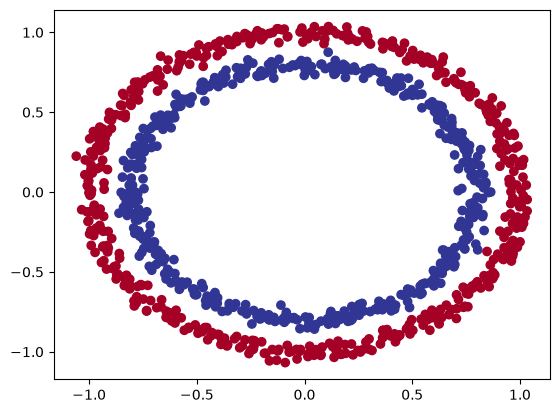

In [5]:
import matplotlib.pyplot as plt

plt.scatter(x=circles['X1'], y=circles['X2'], c=y, cmap=plt.cm.RdYlBu)
plt.show();

In [6]:
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
import torch

X = torch.from_numpy(X)
y = torch.from_numpy(y)

X[0], y[0]

(tensor([0.7542, 0.2315], dtype=torch.float64), tensor(1))

In [8]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [9]:
X_test.dtype

torch.float64

In [10]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [11]:
class CirclesModelV1(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=2, out_features=5, dtype=torch.float64)
        self.layer2 = nn.Linear(in_features=5, out_features=1, dtype=torch.float64)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)

        return x

model1 = CirclesModelV1().type(torch.float)
model1

CirclesModelV1(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [12]:
# Make predictions with the model
untrained_preds = model1(X_test.float().to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.0041],
        [ 0.0144],
        [-0.2816],
        [ 0.0754],
        [-0.6449],
        [-0.6308],
        [-0.2907],
        [-0.4427],
        [-0.2658],
        [ 0.0116]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1, 0, 1, 0, 1, 1, 0, 0, 1, 0])


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def accuracy_fn(original, prediction):
    correct = torch.eq(original, prediction)
    acc = (correct / len(prediction)) * 100
    return acc

def plot_decision_boundary(model : torch.nn.Module, X:torch.tensor, y:torch.tensor):

    model.to('cpu')
    X, y = X.to('cpu'), y.to('cpu')

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    prediction = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    model.eval()
    with torch.inference_mode():
        y_logits = model(prediction)

    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))

    y_pred = y_pred.reshape(xx.shape).detach().numpy()

    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

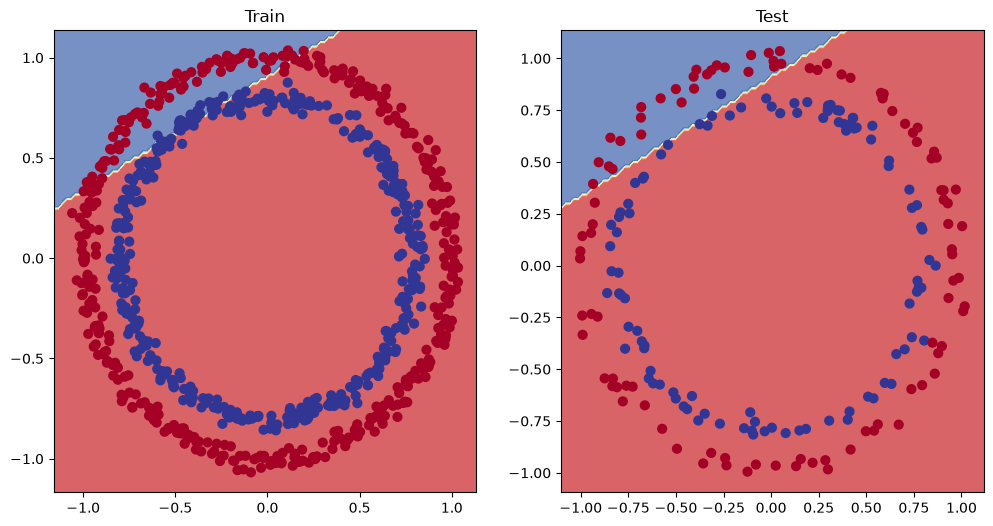

In [14]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model1, X_test, y_test)

In [15]:
class CirclesModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(2, 10)
        self.layer2 = nn.Linear(10, 10)
        self.layer3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))

        return x


model2 = CirclesModelV2().to(device)

In [16]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model2.parameters(), lr = 0.1)

In [26]:
torch.manual_seed(42)

epochs = 100

X_train,y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

train_loss_values = []
test_loss_values = []
train_acc_score = []
test_acc_score = []
epoch_counts = []

for epoch in range(epochs):

    model2.to(device)
    model2.train()

    y_logits = model2(X_train.float()).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train.float())
    acc = accuracy_fn(original=y_train, prediction=y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model2.eval()
    with torch.inference_mode():
        test_logits = model2(X_test.float()).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test.float())
        test_acc = accuracy_fn(original=y_test, prediction=test_preds)

        if epoch % 10 == 0:
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())

            train_acc_score.append(acc[0])
            test_acc_score.append(test_acc[0])

            epoch_counts.append(epoch)

print('Ok')

Ok


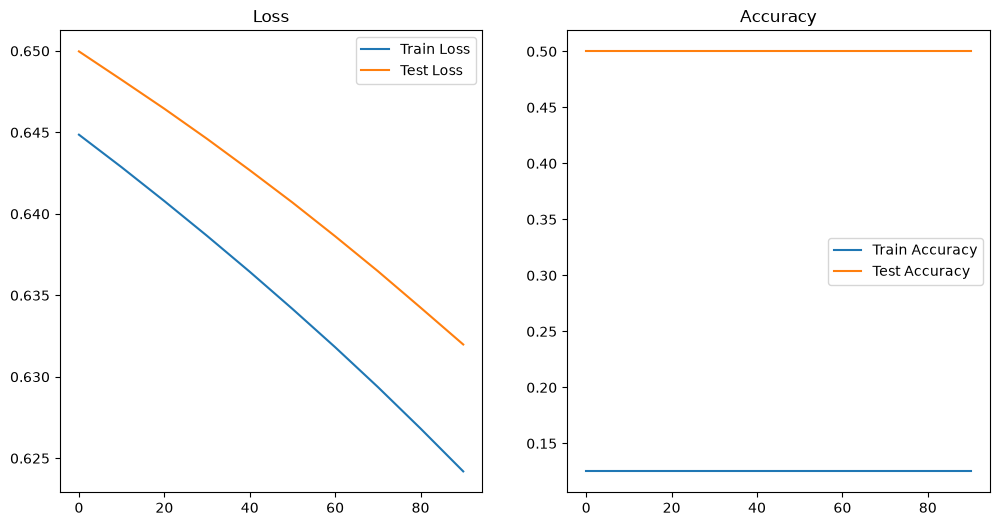

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].set_title('Loss')
ax[0].plot(epoch_counts, train_loss_values, label='Train Loss')
ax[0].plot(epoch_counts, test_loss_values, label='Test Loss')
ax[0].legend()
ax[1].set_title('Accuracy')
ax[1].plot(epoch_counts, train_acc_score, label='Train Accuracy')
ax[1].plot(epoch_counts, test_acc_score, label='Test Accuracy')
ax[1].legend()
plt.show()

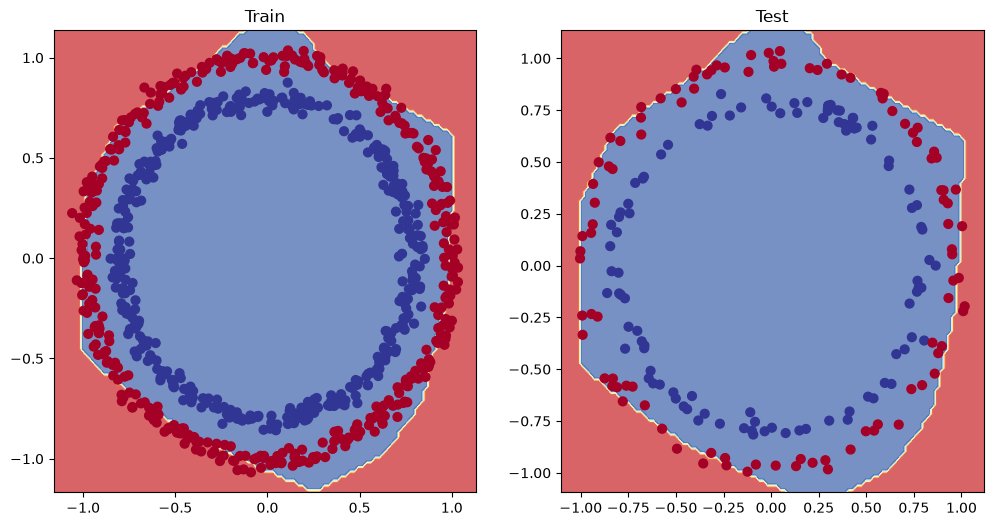

In [28]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model2, X_test, y_test)